<a href="https://colab.research.google.com/github/SyedSameena18/FUTURE_DS_03/blob/main/Task1_Business_Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [4]:
import zipfile
with zipfile.ZipFile('/content/Sample - Superstore.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [5]:
import os
os.listdir('/content/')

['.config',
 'Sample - Superstore.csv',
 'Sample - Superstore.csv.zip',
 'sample_data']

In [6]:
import zipfile
with zipfile.ZipFile('/content/Sample - Superstore.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [7]:
os.listdir('/content/')

['.config',
 'Sample - Superstore.csv',
 'Sample - Superstore.csv.zip',
 'sample_data']

In [8]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

DATA CLEANING

1. Data Inspection


In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [11]:
df.shape

(9994, 21)

In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
print(df.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


2. Check Datatypes


In [15]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


3. Check Missing Values

In [16]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [17]:
df.dropna(inplace=True)

4. Removing Duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

KPI METRICS


1. Total Sales KPI

In [21]:
total_sales = df['Sales'].sum()
print("Total Sales:", round(total_sales, 2))

Total Sales: 2297200.86


2. Total Profit KPI

In [22]:
total_profit = df['Profit'].sum()
print("Total Profit:", round(total_profit, 2))

Total Profit: 286397.02


DATA VISUALIZATION


1. Top Selling Categories - Technology generated the highest sales among all categories, indicating strong customer demand and revenue contribution. Categories with lower sales may require targeted marketing and promotional strategies to improve performance.

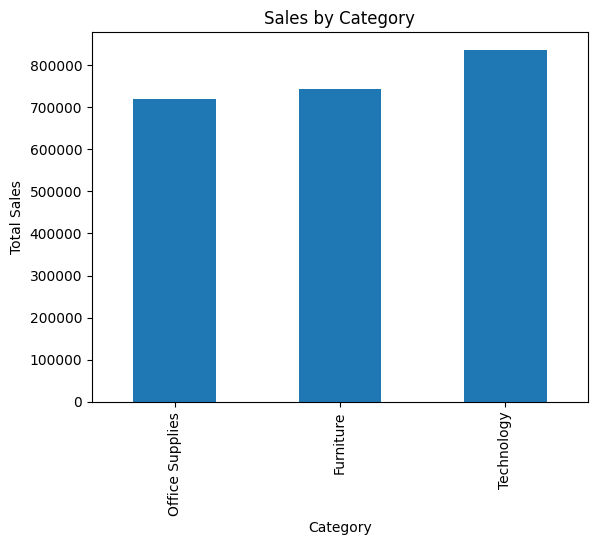

In [23]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

2. Region Performance Analysis - Sales performance varies across regions, with some regions contributing significantly more revenue than others. High-performing regions should be prioritized for expansion, while underperforming regions require further market analysis.

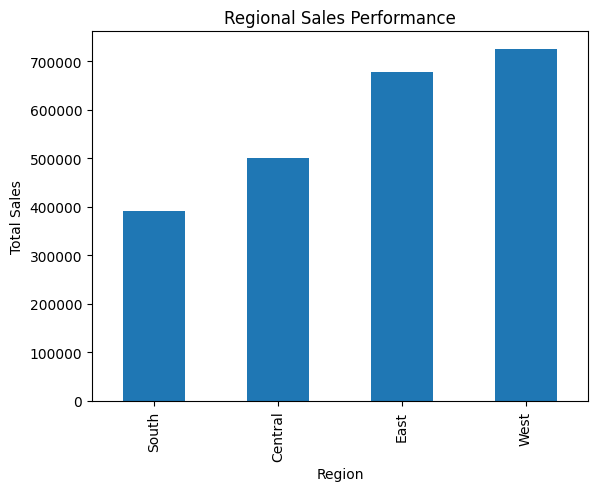

In [24]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
region_sales.plot(kind='bar')
plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

3. Top Sub-Categories - Certain sub-categories contribute a major share of overall sales, making them key revenue drivers for the business. Low-performing sub-categories may need inventory optimization or revised sales strategies.



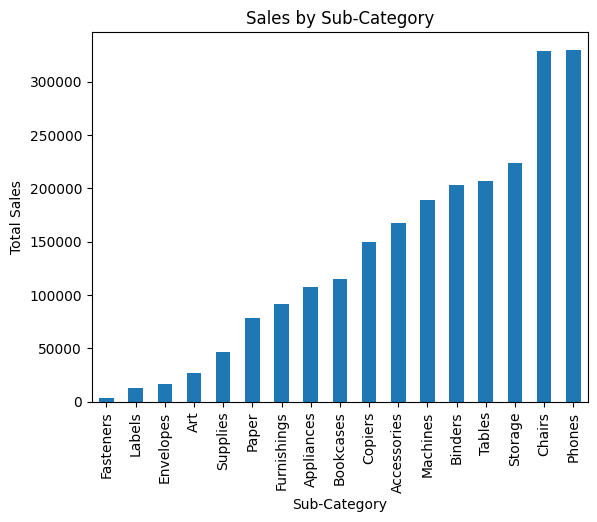

In [25]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()
sub_category_sales.plot(kind='bar')
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.show()

4. Monthly Sales Trend - Sales fluctuate throughout the year, indicating seasonal demand patterns. Peak sales periods present opportunities for targeted promotions, while slower periods may require additional marketing efforts to maintain revenue growth.

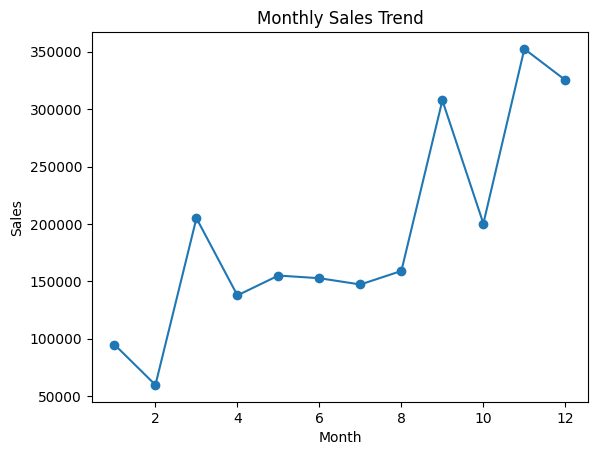

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

5. Top Profitable States - A small number of states generate a significant portion of total profit. These high-performing markets demonstrate strong business potential and should be prioritized for customer retention and growth initiatives.

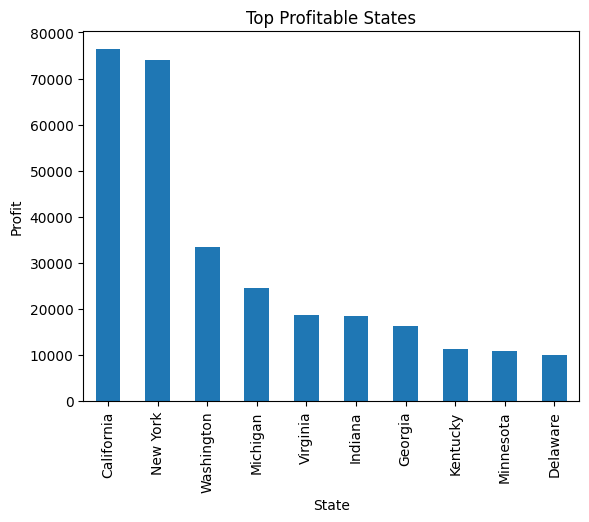

In [28]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)
state_profit.plot(kind='bar')
plt.title("Top Profitable States")
plt.xlabel("State")
plt.ylabel("Profit")
plt.show()

BUSINESS INSIGHTS -

1. Technology products contribute the highest share of sales revenue.

2. Regional performance differs considerably, highlighting opportunities for market-specific strategies.

3. A limited number of sub-categories drive the majority of sales.

4. Sales trends indicate seasonal variations in customer purchasing behavior.

5. Profit generation is concentrated within a few high-performing states.

6. Strategic focus on top-performing products, regions, and markets can improve overall business growth.

In [ ]:
BUSINESS RECOMMENDATIONS -

1. Increase investment in high-performing product categories to maximize revenue growth.

2. Expand marketing efforts in underperforming regions to improve sales performance.

3. Focus inventory management on top-selling sub-categories.

4. Plan promotional campaigns around seasonal sales trends.

5. Replicate successful sales strategies from highly profitable states in other regions.

6. Continuously monitor sales KPIs and customer demand patterns to support data-driven decision making.